# Bottom-Left法を実装する

In [1]:
import ortools

ModuleNotFoundError: No module named 'ortools'

In [2]:
from pathlib import Path 

class Env:

    def __init__(self, input_txt_path: Path):
        self.W, self.D, self.N, self.a = self._input(input_txt_path)

    def _input(self, txt_path):
        with open(txt_path, mode="r") as file:
            lines = file.readlines()
        W, D, N = map(int, lines[0].split())
        a = []
        for line, d in zip(lines[1:], range(D)):
            d = list(map(int, line.split()))
            a.append(d)
        return W, D, N, a

In [3]:
sample_txt_path = Path("tools/in/0001.txt")
env = Env(sample_txt_path)

In [4]:
import random
import math

class Rectangle:
    def __init__(self, area, width, height, min_len, max_len, x=0, y=0):
        self.area = area
        self.width = width
        self.height = height
        self.min_len = min_len
        self.max_len = max_len
        self.x = x
        self.y = y

    def random_resize(self):
        change_len = max(0, int(self.area ** 0.5 * 0.2))
        if random.random() < 0.5:
            next_w = random.randint(max(self.min_len, self.width - change_len), min(self.max_len, self.width + change_len))
            next_h = math.ceil(self.area / next_w)
        else:
            next_h = random.randint(max(self.min_len, self.height - change_len), min(self.max_len, self.height + change_len))
            next_w = math.ceil(self.area / next_h)            
        self.width = next_w
        self.height = next_h

    def __str__(self):
        return f"Rectangle({self.width}, {self.height})"

In [5]:
import math
import random

rectangles: list[Rectangle] = []
for area in env.a[0]:
    divs = []
    for div1 in range(1, 1000 + 1):
        div2 = math.ceil(area / div1)
        if 1 <= div1 <= 1000 and 1 <= div2 <= 1000:
            divs.append(div1)
            divs.append(div2)
    min_len = min(divs)
    max_len = max(divs)
    if random.random() < 0.5:
        w = random.randint(min_len, max_len)
        h = math.ceil(area / w)
    else:
        h = random.randint(min_len, max_len)
        w = math.ceil(area / h)
    rectangles.append(Rectangle(
        area=area,
        width=w,
        height=h,
        min_len=min_len,
        max_len=max_len
    ))
rectangles = sorted(rectangles, key=lambda x: x.height, reverse=True)

NameError: name 'best_x' is not defined

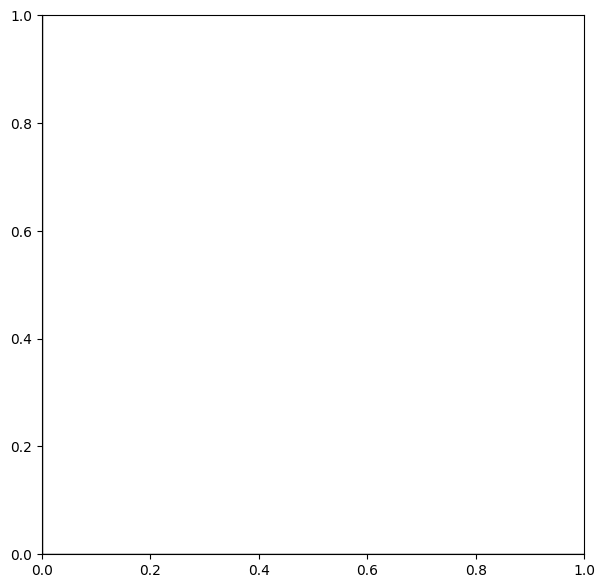

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig = plt.figure(figsize=(7, 7))
ax = plt.axes()

r = patches.Rectangle(xy=(0, 0), width=1000, height=1000, ec='#000000', fill=False)
ax.add_patch(r)

for x,y,w,h in zip(best_x, best_y, best_w, best_h):
    r = patches.Rectangle(xy=(x,y), width=w, height=h, ec='#000000', fill=True)
    ax.add_patch(r)

plt.xlim(-5, 1500)
plt.ylim(-5, 1500)
plt.axis('off')
ax.set_aspect('equal')